<a href="https://colab.research.google.com/github/ClaudioRo81/Data_Scientist/blob/main/practica2_Rojas_Duran_Claudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 2 — Análisis exploratorio de `international_matches.csv`

**Contenido del notebook**
1. Estadísticas descriptivas
2. Selección y justificación de 3 variables representativas
3. Visualización de datos (varios gráficos)
4. Valores faltantes por atributo
5. Transformación de valores faltantes / datos "raros"
6. Matriz de correlación e interpretación
7. Conclusiones: 4 recomendaciones para México

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

Importamos las librerías que usaremos en todo el notebook: `pandas`/`numpy` para manejo de datos, `matplotlib`/`seaborn` para visualización y `re` para detectar patrones de texto en las fechas.

In [3]:
CSV = "international_matches.csv"

df = pd.read_csv(CSV)
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 17770 filas x 9 columnas


,ID,Tournament,Date,Home Team,Home Goals,Away Goals,Away Team,Win Conditions,Home Stadium
0,1,Friendly,1872-11-30,Scotland,0.0,0.0,England,NaN,TRUE
1,2,Friendly,1873-03-08,England,4.0,2.0,Scotland,NaN,TRUE
2,3,Friendly,1874-03-07,Scotland,2.0,1.0,England,NaN,TRUE
3,4,Friendly,1875-03-06,England,2.0,2.0,Scotland,NaN,TRUE
4,5,Friendly,1876-03-04,Scotland,3.0,0.0,England,NaN,TRUE


El dataset tiene **17,770 partidos internacionales de fútbol** con 9 columnas: identificador, torneo, fecha, equipos local/visitante, goles de cada uno, condición de victoria (p. ej. penales) y si se jugó en el estadio del equipo local. Todas las columnas se cargan como texto, incluida `Date`, cuyo formato exploramos a continuación.

In [5]:
# Diagnóstico de los formatos de fecha presentes en el dataset
patrones = df["Date"].astype(str).apply(lambda x: re.sub(r"\d", "0", x)).value_counts()
patrones

,count
Date,
0/00/0000,8792
0/0/0000,4130
00/00/0000,3636
00/0/0000,1100
0000-00-00,111
0/00/00000,1


La columna `Date` mezcla varios formatos de fecha. También se confirma que existe un patrón con un dígito extra en el año (una fecha "rara" que corregiremos en un momento). Para saber si el formato con `/` es `M/D/YYYY` o `D/M/YYYY`, verificamos que **ningún primer número supera 12**, mientras que sí hay **segundos números mayores a 12** (días 13 a 31); esto confirma que el orden es mes/día/año.

In [6]:
def parse_fecha(valor):
    """
    Convierte las fechas del dataset a datetime, soportando los dos
    formatos detectados:
      - 'YYYY-MM-DD'
      - 'M/D/YYYY'
    Corrige además un caso atípico con un dígito extra en el año
    (ej. '3/28/20211' -> '3/28/2021').
    """
    texto = str(valor).strip()

    if "-" in texto:
        return pd.to_datetime(texto, format="%Y-%m-%d", errors="coerce")

    if "/" in texto:
        partes = texto.split("/")
        if len(partes) == 3 and len(partes[2]) > 4:
            partes[2] = partes[2][:4]
            texto = "/".join(partes)
        return pd.to_datetime(texto, format="%m/%d/%Y", errors="coerce")

    return pd.NaT


df["Date_parsed"] = df["Date"].apply(parse_fecha)
df["Year"] = df["Date_parsed"].dt.year
df["Month"] = df["Date_parsed"].dt.month

print("Fechas que no se pudieron convertir:", df["Date_parsed"].isna().sum())
df[["Date", "Date_parsed", "Year"]].head()

Fechas que no se pudieron convertir: 0


,Date,Date_parsed,Year
0,1872-11-30,1872-11-30,1872
1,1873-03-08,1873-03-08,1873
2,1874-03-07,1874-03-07,1874
3,1875-03-06,1875-03-06,1875
4,1876-03-04,1876-03-04,1876


Todas las fechas se convirtieron correctamente a formato `datetime`, incluida la fecha corrupta. A partir de aquí trabajamos con `Date_parsed` (fecha real) y las columnas derivadas `Year` y `Month`, que usaremos en los análisis y gráficos posteriores.

In [7]:
# Aseguramos que los goles sean numéricos y creamos variables derivadas
df["Home Goals"] = pd.to_numeric(df["Home Goals"], errors="coerce")
df["Away Goals"] = pd.to_numeric(df["Away Goals"], errors="coerce")
df["TotalGoals"] = df["Home Goals"] + df["Away Goals"]
df["GoalDiff"] = df["Home Goals"] - df["Away Goals"]

df[["Home Goals", "Away Goals", "TotalGoals", "GoalDiff"]].describe()

,Home Goals,Away Goals,TotalGoals,GoalDiff
count,17769.000000,17769.000000,17769.000000,17769.000000
mean,1.722382,1.169002,2.891384,0.553379
std,1.692834,1.335989,2.016372,2.288088
min,0.000000,0.000000,0.000000,-17.000000
25%,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,1.000000,3.000000,0.000000
75%,2.000000,2.000000,4.000000,2.000000
max,31.000000,17.000000,31.000000,31.000000


**Conclusión (estadísticas descriptivas #1 - variables numéricas):** en promedio el equipo **local anota más goles** (media ≈ 1.7) que el visitante (media ≈ 1.2), y `GoalDiff` tiene media positiva, lo que sugiere una ventaja de local clara en el fútbol internacional. La desviación estándar (≈1.3–1.7) es alta en relación con la media, algo esperado del fútbol, donde marcadores altos son poco comunes.

In [9]:
print("Moda de goles del local:", df["Home Goals"].mode().tolist())
print("Moda de goles del visitante:", df["Away Goals"].mode().tolist())
print("Asimetría de TotalGoals:", round(df["TotalGoals"].skew(), 3))

print("\nTop 10 selecciones locales con más partidos:")
print(df["Home Team"].value_counts().head(10))

print("\nTop 5 torneos más comunes:")
print(df["Tournament"].value_counts().head(5))

Moda de goles del local: [1.0]
Moda de goles del visitante: [0.0]
Asimetría de TotalGoals: 1.249

Top 10 selecciones locales con más partidos:
Home Team
Mexico           520
Brazil           507
Argentina        505
England          485
South Korea      476
France           461
Germany          448
United States    431
Denmark          413
Netherlands      411
Name: count, dtype: int64

Top 5 torneos más comunes:
Tournament
Friendly                                7870
FIFA World Cup qualification            3542
UEFA Euro qualification                 1215
Copa America                             639
African Cup of Nations qualification     436
Name: count, dtype: int64


**Conclusión (estadísticas descriptivas #2 - moda, asimetría y frecuencias):** la moda de goles, tanto local como visitante, es **1**, y `TotalGoals` tiene asimetría positiva (cola larga a la derecha), confirmando que los marcadores altos son raros. El torneo más frecuente es **"Friendly"** (amistosos), y algunas selecciones concentran muchos más partidos que otras, lo cual es un reflejo de su historia futbolística.

## Selección de las 3 variables más representativas

**Variables seleccionadas:** `Home Goals`, `Away Goals` y `Tournament`.

**Justificación:**
- `Home Goals` y `Away Goals` son el núcleo cuantitativo del dataset: de ellas se derivan el resultado (ganó/perdió/empató), la diferencia de goles y los goles totales, que son las métricas más usadas para evaluar desempeño deportivo.
- `Tournament` es la variable categórica más informativa porque contextualiza el partido (amistoso vs. eliminatoria vs. copa continental); el nivel de exigencia/competitividad cambia mucho entre categorías y afecta directamente los goles y el resultado.
- Se descartaron variables como `Win Conditions` (~98% de datos faltantes) y `Home Stadium` (casi constante, poco aporte analítico) porque agregan poca información nueva frente a las tres seleccionadas.

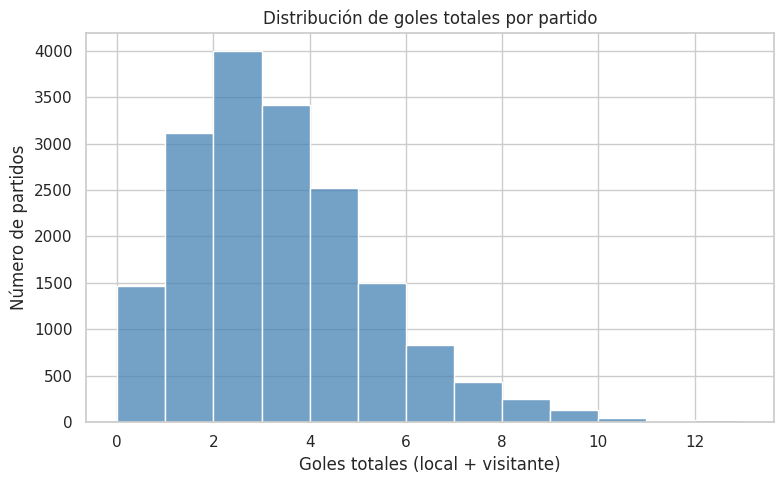

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["TotalGoals"].dropna(), bins=range(0, 14), kde=False, color="steelblue")
plt.title("Distribución de goles totales por partido")
plt.xlabel("Goles totales (local + visitante)")
plt.ylabel("Número de partidos")
plt.tight_layout()
plt.show()

**Conclusión (gráfico 1 - histograma de goles):** la distribución de goles totales está **sesgada a la derecha**: la mayoría de los partidos tienen entre 1 y 4 goles totales, y marcadores muy altos (7+) son poco frecuentes.

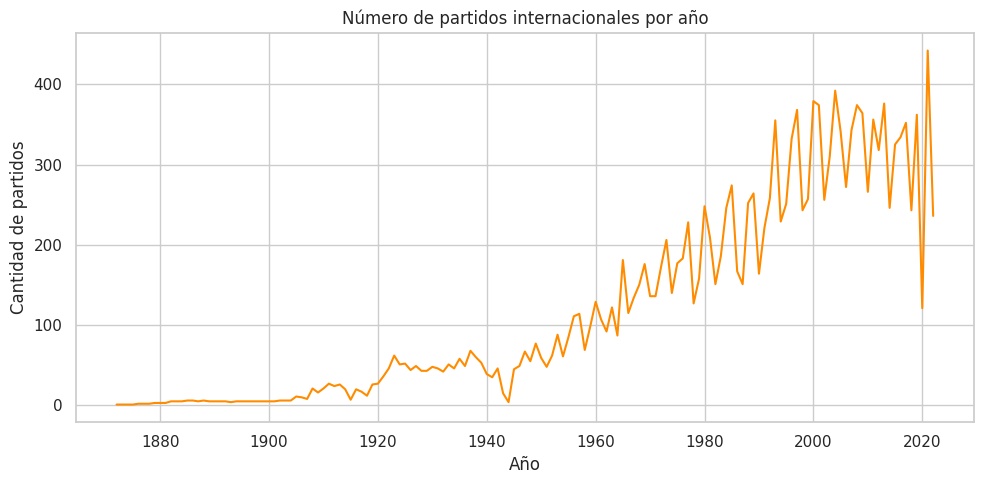

In [11]:
partidos_por_anio = df["Year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(partidos_por_anio.index, partidos_por_anio.values, color="darkorange")
plt.title("Número de partidos internacionales por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de partidos")
plt.tight_layout()
plt.show()

**Conclusión (gráfico 2 - serie temporal de partidos):** la cantidad de partidos internacionales por año **crece con el tiempo**, con mayor actividad a partir de la segunda mitad del siglo XX, lo que refleja la expansión de las federaciones de fútbol y de los torneos oficiales (Copa del Mundo, Copa Oro, eliminatorias, etc.).

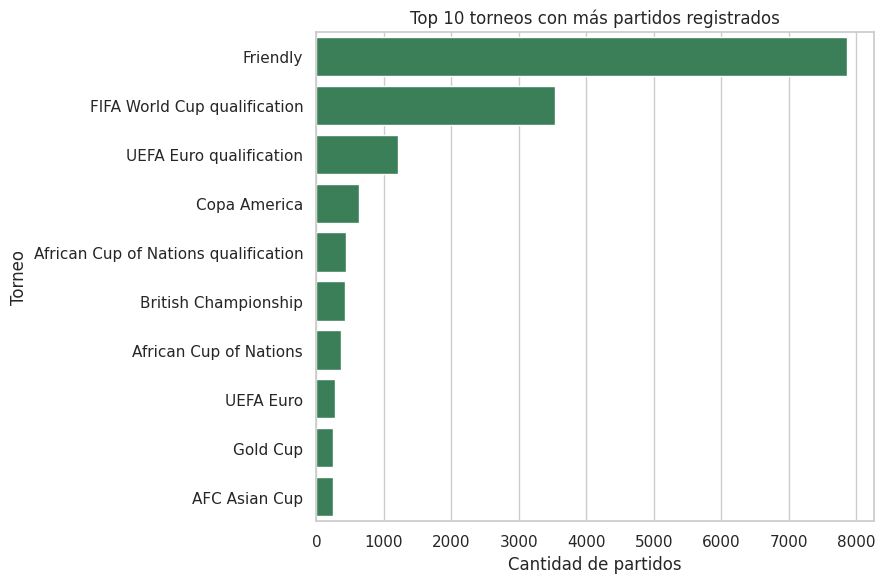

In [12]:
top_torneos = df["Tournament"].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_torneos.values, y=top_torneos.index, color="seagreen")
plt.title("Top 10 torneos con más partidos registrados")
plt.xlabel("Cantidad de partidos")
plt.ylabel("Torneo")
plt.tight_layout()
plt.show()

**Conclusión (gráfico 3 - barras de torneos):** **"Friendly"** domina claramente el conteo de partidos, seguido por las eliminatorias de la Copa del Mundo (FIFA World Cup qualification) y las eliminatorias/torneos continentales (UEFA Euro, Copa América, Copa Africana de Naciones), lo que confirma que gran parte del calendario internacional se compone de partidos amistosos.

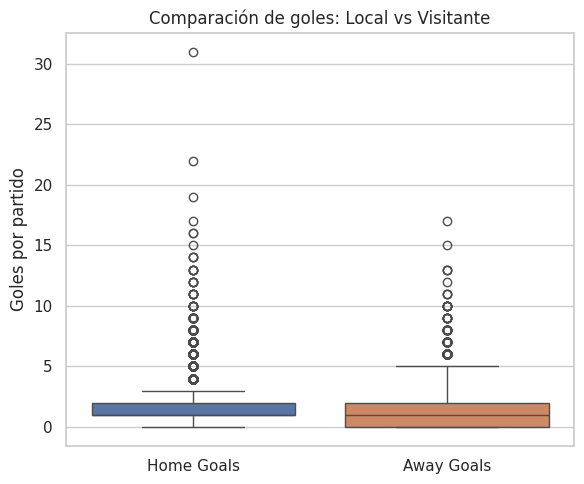

In [13]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df[["Home Goals", "Away Goals"]])
plt.title("Comparación de goles: Local vs Visitante")
plt.ylabel("Goles por partido")
plt.tight_layout()
plt.show()

**Conclusión (gráfico 4 - boxplot):** el boxplot confirma visualmente la **ventaja de local**: tanto la mediana como el rango intercuartílico de goles del equipo local están por encima de los del visitante.

In [15]:
faltantes = df.isna().sum().sort_values(ascending=False)
porcentaje = (faltantes / len(df) * 100).round(2)
tabla_faltantes = pd.DataFrame({"Faltantes": faltantes, "Porcentaje (%)": porcentaje})
tabla_faltantes

,Faltantes,Porcentaje (%)
Win Conditions,17569,98.87
Home Goals,1,0.01
Away Goals,1,0.01
TotalGoals,1,0.01
Away Team,1,0.01
Home Team,1,0.01
GoalDiff,1,0.01
Date,0,0.00
ID,0,0.00
Tournament,0,0.00


**Conclusión de valores faltantes:** `Win Conditions` concentra casi todos los valores faltantes (~98%), porque solo se llena cuando el partido se definió en circunstancias especiales (p. ej. penales); un partido "normal" no requiere esa columna, así que el vacío **no es un error**, sino la ausencia de un evento. Columnas como `Home Goals`, `Away Goals` y `Home Team` tienen apenas 1 valor faltante cada una, probablemente un registro incompleto puntual.

In [16]:
df_transformado = df.copy()

# a) 'Win Conditions': el NaN no es un dato perdido real, sino "no aplica".
#    Se transforma en una variable booleana más útil para el análisis.
df_transformado["Went_to_penalties"] = df_transformado["Win Conditions"].notna()

# b) Goles faltantes (dato realmente perdido, no derivable):
#    se imputan con la mediana de goles de ese mismo torneo.
for col in ["Home Goals", "Away Goals"]:
    df_transformado[col] = df_transformado.groupby("Tournament")[col].transform(
        lambda serie: serie.fillna(serie.median())
    )

# c) 'Home Stadium' tiene un valor inconsistente 'TBD' (no es TRUE/FALSE);
#    se trata como dato faltante, no como tercera categoría válida.
df_transformado["Home Stadium"] = df_transformado["Home Stadium"].replace("TBD", np.nan)

print("Valores únicos de 'Home Stadium' después de la limpieza:")
print(df_transformado["Home Stadium"].unique())
df_transformado[["Win Conditions", "Went_to_penalties"]].head(3)

Valores únicos de 'Home Stadium' después de la limpieza:
['TRUE' 'FALSE' nan]


,Win Conditions,Went_to_penalties
0,NaN,False
1,NaN,False
2,NaN,False


En vez de eliminar `Win Conditions` por su alto porcentaje de NaN, se recodificó como bandera booleana (`Went_to_penalties`), que sí es aprovechable estadísticamente. Los pocos goles faltantes se imputaron con la **mediana del torneo correspondiente** (más robusta que la media, dado que la distribución de goles tiene cola derecha), y el valor inconsistente `'TBD'` en `Home Stadium` se normalizó como valor faltante en vez de dejarlo como una tercera categoría espuria.

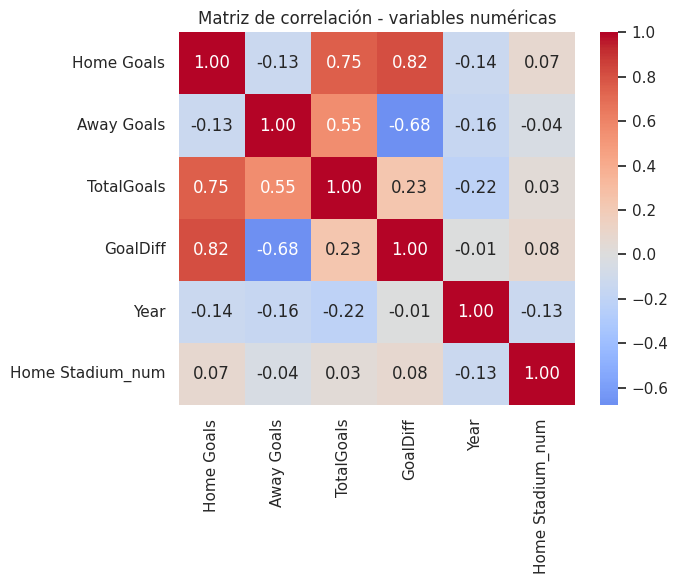

,Home Goals,Away Goals,TotalGoals,GoalDiff,Year,Home Stadium_num
Home Goals,1.00,-0.13,0.75,0.82,-0.14,0.07
Away Goals,-0.13,1.00,0.55,-0.68,-0.16,-0.04
TotalGoals,0.75,0.55,1.00,0.23,-0.22,0.03
GoalDiff,0.82,-0.68,0.23,1.00,-0.01,0.08
Year,-0.14,-0.16,-0.22,-0.01,1.00,-0.13
Home Stadium_num,0.07,-0.04,0.03,0.08,-0.13,1.00


In [17]:
df_transformado["Home Stadium_num"] = df_transformado["Home Stadium"].map({"TRUE": 1, "FALSE": 0})

variables_corr = df_transformado[
    ["Home Goals", "Away Goals", "TotalGoals", "GoalDiff", "Year", "Home Stadium_num"]
]

matriz_corr = variables_corr.corr(numeric_only=True)

plt.figure(figsize=(7, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación - variables numéricas")
plt.tight_layout()
plt.show()

matriz_corr.round(2)

**Conclusión (matriz de correlación):** `Home Goals` y `GoalDiff` están fuertemente correlacionados de forma positiva (lógico, porque `GoalDiff = Home Goals - Away Goals`), mientras que `Away Goals` y `GoalDiff` se correlacionan negativamente por la misma razón algebraica. `Home Goals` y `Away Goals` entre sí tienen correlación cercana a 0, indicando que el desempeño ofensivo de un equipo **no depende linealmente** del desempeño del rival. `Year` muestra correlación débil con los goles, sugiriendo que el promedio de goles por partido no ha cambiado drásticamente con el tiempo. `Home Stadium_num` (jugar en casa) tiene correlación positiva ligera con `Home Goals` y `GoalDiff`, reforzando cuantitativamente la ventaja de local vista en los gráficos.

In [18]:
mexico = df_transformado[
    (df_transformado["Home Team"] == "Mexico") | (df_transformado["Away Team"] == "Mexico")
].copy()


def goles_mexico(fila):
    if fila["Home Team"] == "Mexico":
        return pd.Series([fila["Home Goals"], fila["Away Goals"], True])
    else:
        return pd.Series([fila["Away Goals"], fila["Home Goals"], False])


mexico[["GF", "GC", "EsLocal"]] = mexico.apply(goles_mexico, axis=1)

resumen_mexico = {
    "Partidos totales": len(mexico),
    "Prom. goles a favor (local)": mexico.loc[mexico.EsLocal, "GF"].mean(),
    "Prom. goles en contra (local)": mexico.loc[mexico.EsLocal, "GC"].mean(),
    "Prom. goles a favor (visitante)": mexico.loc[~mexico.EsLocal, "GF"].mean(),
    "Prom. goles en contra (visitante)": mexico.loc[~mexico.EsLocal, "GC"].mean(),
    "% victorias como local": (mexico.loc[mexico.EsLocal, "GF"] > mexico.loc[mexico.EsLocal, "GC"]).mean() * 100,
    "% victorias como visitante": (mexico.loc[~mexico.EsLocal, "GF"] > mexico.loc[~mexico.EsLocal, "GC"]).mean() * 100,
}

for k, v in resumen_mexico.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

print("\nTorneos donde México ha jugado con más frecuencia:")
print(mexico["Tournament"].value_counts().head(5))

Partidos totales: 864
Prom. goles a favor (local): 2.02
Prom. goles en contra (local): 0.87
Prom. goles a favor (visitante): 1.39
Prom. goles en contra (visitante): 1.23
% victorias como local: 59.62
% victorias como visitante: 40.70

Torneos donde México ha jugado con más frecuencia:
Tournament
Friendly                        454
FIFA World Cup qualification    153
Gold Cup                         79
Copa America                     48
CONCACAF Championship            39
Name: count, dtype: int64


**Conclusión del análisis específico de México:** con 864 partidos históricos, México **gana cerca del 60% como local** (2.02 goles a favor / 0.87 en contra en promedio) contra solo **≈41% como visitante** (1.39 a favor / 1.23 en contra). La brecha entre jugar en casa y de visita es notablemente mayor a la del fútbol internacional en general, y la mayoría de sus partidos históricos han sido amistosos, seguidos de eliminatorias mundialistas y Copa Oro.

## Conclusiones: 4 recomendaciones para México

1. **Aprovechar y proteger la ventaja de local:** México gana cerca del 60% de sus partidos como local, contra ~41% como visitante, con un promedio de goles a favor casi el doble que fuera de casa (2.0 vs 1.4). Se recomienda priorizar sedes de alta altitud/afición (p. ej. Estadio Azteca) en partidos de eliminatoria decisivos aunque seria ganar con ventaja futbolisticamente no lo es jeje.

2. **Reforzar el desempeño defensivo fuera de casa:** como visitante, México recibe en promedio más goles (1.23) que como local (0.87). Se recomienda trabajar esquemas defensivos y manejo de partido específicamente para viajes, ya que ahí se concentra la mayor brecha de rendimiento.

3. **Priorizar la exposición a partidos de alta competitividad:** la mayoría de los partidos históricos de México son amistosos, seguidos por eliminatorias mundialistas y Copa Oro. Se recomienda aumentar amistosos contra selecciones de ranking FIFA más alto (fuera de CONCACAF) para cerrar la brecha de nivel antes de torneos como el Mundial.

4. **Monitorear la tendencia de goles a lo largo del tiempo:** dado que el promedio general de goles por partido no muestra una tendencia fuerte con los años, la mejora de México debe venir de gestión táctica y de plantilla.